# Hyperparameter grid search v2 — Norman 2019 (100 % gamma 1.1)

Anchored at the best setting from grid search v1 (`alpha_mmd=20, beta_kld=0.5`), this notebook
explores finer variations and runs **all three models** for every setting:

- **CMVAE-full**: `use_tf_only=False, use_GRN_priors=False, z_dim=None`
- **CMVAE-comp**: `use_tf_only=False, use_GRN_priors=False, z_dim=n_eig`  (same z as gCRL-VAE)
- **gCRL-VAE**:   `use_tf_only=True,  use_GRN_priors=True,  z_dim=None`

Note: `lambda_mcc` is ignored by both CMVAE variants (zeroed in the trainer when
`use_GRN_priors=False`); only gCRL-VAE is affected by it.

| # | Name | Change from anchor | Rationale |
|---|---|---|---|
| 1 | `mmd20_kld05` | — | Carry-over of v1 best; reference for this grid |
| 2 | `mmd20_kld05_b64` | + batch_size=64 | Setting 04 in v1 showed batch64 helps with mmd20; never combined with kld05 |
| 3 | `mmd30` | alpha_mmd=30 | Is mmd=20 saturating, or does more MMD keep helping? |
| 4 | `mmd30_kld05` | alpha_mmd=30, beta_kld=0.5 | Push both axes further |
| 5 | `mmd20_kld01` | beta_kld=0.1 | How low can KLD go before the VAE collapses? |
| 6 | `mmd30_kld01_b64` | alpha_mmd=30, beta_kld=0.1, batch_size=64 | Aggressive end of the spectrum |
| 7 | `mmd20_kld05_sparse01` | + lambda_sparse=0.1 | Sparse interaction with mmd20 never tested |
| 8 | `mmd20_slow_ramp` | epochs=200 | Slower ramp matters more at higher MMD — never tested at mmd=20 |
| 9 | `mmd20_kld05_lr1e4` | + lr=1e-4 | Stabilise optimisation at the best setting |
| 10 | `mmd20_kld05_mcc5` | + lambda_mcc=5.0 | Stronger MCC alignment; active only for gCRL-VAE |


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "../../src")

import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

from gcrl.grn.eigengenes import compute_eigengenes
from gcrl.training.train_gcrl_vae import VAEConfig, train_gcrl_vae
from gcrl.evaluation.prediction_eval import evaluate_predictions

In [3]:
# Control panel
_ctrl_labels = ["unperturbed", "control", "ctrl"]

DATA_PATH = "../../data/real/Norman2019/Norman2019_processed_100pct_gamma1p1.h5ad"
BASE_DIR  = "../../results/real/Norman2019/cmvae_grid_v2"

## 1. Load data and compute eigengenes

In [4]:
adata = ad.read_h5ad(DATA_PATH)
print(f"Loaded: {adata.shape[0]} cells × {adata.shape[1]} genes")

compute_eigengenes(
    adata,
    community_col="community",
    reference_query='intervention == "unperturbed"',
    mode="all_cells",
    method="PC",
    seed=42,
)
eig   = adata.obsm["X_comm_eig"]
n_eig = eig.shape[1]
print(f"Eigengene matrix: {eig.shape}  (n_cells × n_communities+1)")

Loaded: 35048 cells × 2703 genes


Eigengene matrix: (35048, 8)  (n_cells × n_communities+1)


## 2. Define configurations

The anchor (`_base`) is the best setting from v1: `alpha_mmd=20, beta_kld=0.5`.
All other hyperparameters are kept at the original discrepancy-VAE defaults.

In [5]:
# Anchor: best setting from grid search v1
_base = dict(
    alpha_mmd_max  = 20.0,
    beta_kld_max   = 0.5,
    lambda_sparse  = 1e-3,
    lambda_mcc     = 1.0,   # active only for gCRL-VAE; zeroed for CMVAE variants
    lr             = 1e-3,
    batch_size     = 32,
    epochs         = 100,
    seed           = 0,
)

SETTINGS = [
    # (name,                      overrides)
    ("01_mmd20_kld05",            {}),
    ("02_mmd20_kld05_b64",        dict(batch_size=64)),
    ("03_mmd30",                  dict(alpha_mmd_max=30.0)),
    ("04_mmd30_kld05",            dict(alpha_mmd_max=30.0, beta_kld_max=0.5)),
    ("05_mmd20_kld01",            dict(beta_kld_max=0.1)),
    ("06_mmd30_kld01_b64",        dict(alpha_mmd_max=30.0, beta_kld_max=0.1, batch_size=64)),
    ("07_mmd20_kld05_sparse01",   dict(lambda_sparse=0.1)),
    ("08_mmd20_slow_ramp",        dict(epochs=200)),
    ("09_mmd20_kld05_lr1e4",      dict(lr=1e-4)),
    ("10_mmd20_kld05_mcc5",       dict(lambda_mcc=5.0)),
]

# Sub-models to train for every setting
SUBMODELS = [
    ("cmvae_full", dict(use_tf_only=False, use_GRN_priors=False, z_dim=None)),
    ("cmvae_comp", dict(use_tf_only=False, use_GRN_priors=False, z_dim=n_eig)),
    ("gcrl_vae",   dict(use_tf_only=True,  use_GRN_priors=True,  z_dim=None)),
]

print(f"{len(SETTINGS)} settings × {len(SUBMODELS)} models = {len(SETTINGS)*len(SUBMODELS)} runs")

10 settings × 3 models = 30 runs


## 3. Train all configurations

Results are saved after each (setting, model) pair. On re-run, already-completed
runs are skipped automatically.

In [6]:
import os

models    = {}
histories = {}

for name, overrides in SETTINGS:
    for sub_name, sub_kwargs in SUBMODELS:
        key     = (name, sub_name)
        out_dir = f"{BASE_DIR}/{name}/{sub_name}"
        hist_path = f"{out_dir}/training_history.json"

        # Skip if already completed
        if os.path.exists(hist_path):
            print(f"Skipping {name}/{sub_name}  (already done)")
            with open(hist_path) as f:
                histories[key] = pd.DataFrame(json.load(f))
            models[key] = None  # model not needed until evaluation cell
            continue

        print(f"\n{'='*55}")
        print(f"Training: {name} / {sub_name}")
        print(f"{'='*55}")
        cfg_kwargs = {**_base, **overrides, **sub_kwargs}
        cfg = VAEConfig(outdir=out_dir, **cfg_kwargs)
        model, history = train_gcrl_vae(adata, cfg, eigengenes_key="X_comm_eig")
        models[key]    = model
        histories[key] = pd.DataFrame(history)

        # Save history immediately after this run
        os.makedirs(out_dir, exist_ok=True)
        with open(hist_path, "w") as f:
            json.dump(histories[key].to_dict(orient="list"), f)
        print(f"  History saved → {hist_path}")

print("\nAll configurations trained.")


Training: 01_mmd20_kld05 / cmvae_full
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_v2/01_mmd20_kld05/cmvae_full/
  History saved → ../../results/real/Norman2019/cmvae_grid_v2/01_mmd20_kld05/cmvae_full/training_history.json

Training: 01_mmd20_kld05 / cmvae_comp
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_v2/01_mmd20_kld05/cmvae_comp/
  History saved → ../../results/real/Norman2019/cmvae_grid_v2/01_mmd20_kld05/cmvae_comp/training_history.json

Training: 01_mmd20_kld05 / gcrl_vae
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


...

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_v2/10_mmd20_kld05_mcc5/cmvae_full/
  History saved → ../../results/real/Norman2019/cmvae_grid_v2/10_mmd20_kld05_mcc5/cmvae_full/training_history.json

Training: 10_mmd20_kld05_mcc5 / cmvae_comp
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_v2/10_mmd20_kld05_mcc5/cmvae_comp/
  History saved → ../../results/real/Norman2019/cmvae_grid_v2/10_mmd20_kld05_mcc5/cmvae_comp/training_history.json

Training: 10_mmd20_kld05_mcc5 / gcrl_vae
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_v2/10_mmd20_kld05_mcc5/gcrl_vae/
  History saved → ../../results/real/Norman2019/cmvae_grid_v2/10_mmd20_kld05_mcc5/gcrl_vae/training_history.json

All configurations trained.


## 4. Predict and evaluate

In [7]:
_predict_kwargs = dict(
    set_key          = "set",
    intervention_key = "intervention",
    cell_type_key    = "cell_type",
    control_labels   = tuple(_ctrl_labels),
    seed             = 42,
)

metrics = {}

for name, _ in SETTINGS:
    for sub_name, _ in SUBMODELS:
        key      = (name, sub_name)
        out_dir  = f"{BASE_DIR}/{name}/{sub_name}"
        csv_path = f"{out_dir}/prediction_metrics.csv"

        # Reload from disk if already evaluated
        if os.path.exists(csv_path):
            print(f"Skipping eval {name}/{sub_name}  (already done)")
            metrics[key] = pd.read_csv(csv_path)
            continue

        preds = models[key].predict(adata, **_predict_kwargs)
        metrics[key] = evaluate_predictions(
            adata          = adata,
            preds          = preds,
            output_dir     = out_dir,
            control_labels = tuple(_ctrl_labels),
        )
        cd = metrics[key].query("metric_name == 'centroid_distance' and method == 'actual'")["metric_value"].median()
        wc = metrics[key].query("metric_name == 'centroid_distance' and method == 'worst_case'")["metric_value"].median()
        print(f"{name}/{sub_name:<12}  actual={cd:.4f}  worst_case={wc:.4f}")

print("\nAll evaluations complete.")

01_mmd20_kld05/cmvae_full    actual=4.9240  worst_case=5.4667


01_mmd20_kld05/cmvae_comp    actual=7.7431  worst_case=5.4667


01_mmd20_kld05/gcrl_vae      actual=6.6207  worst_case=5.4667


02_mmd20_kld05_b64/cmvae_full    actual=5.4144  worst_case=5.4667


02_mmd20_kld05_b64/cmvae_comp    actual=7.7762  worst_case=5.4667


...

09_mmd20_kld05_lr1e4/cmvae_comp    actual=7.1380  worst_case=5.4667


09_mmd20_kld05_lr1e4/gcrl_vae      actual=9.6393  worst_case=5.4667


10_mmd20_kld05_mcc5/cmvae_full    actual=4.9240  worst_case=5.4667


10_mmd20_kld05_mcc5/cmvae_comp    actual=7.7431  worst_case=5.4667


10_mmd20_kld05_mcc5/gcrl_vae      actual=6.6928  worst_case=5.4667

All evaluations complete.


## 5. Training curves

One panel per loss component; one line per setting, coloured by sub-model.

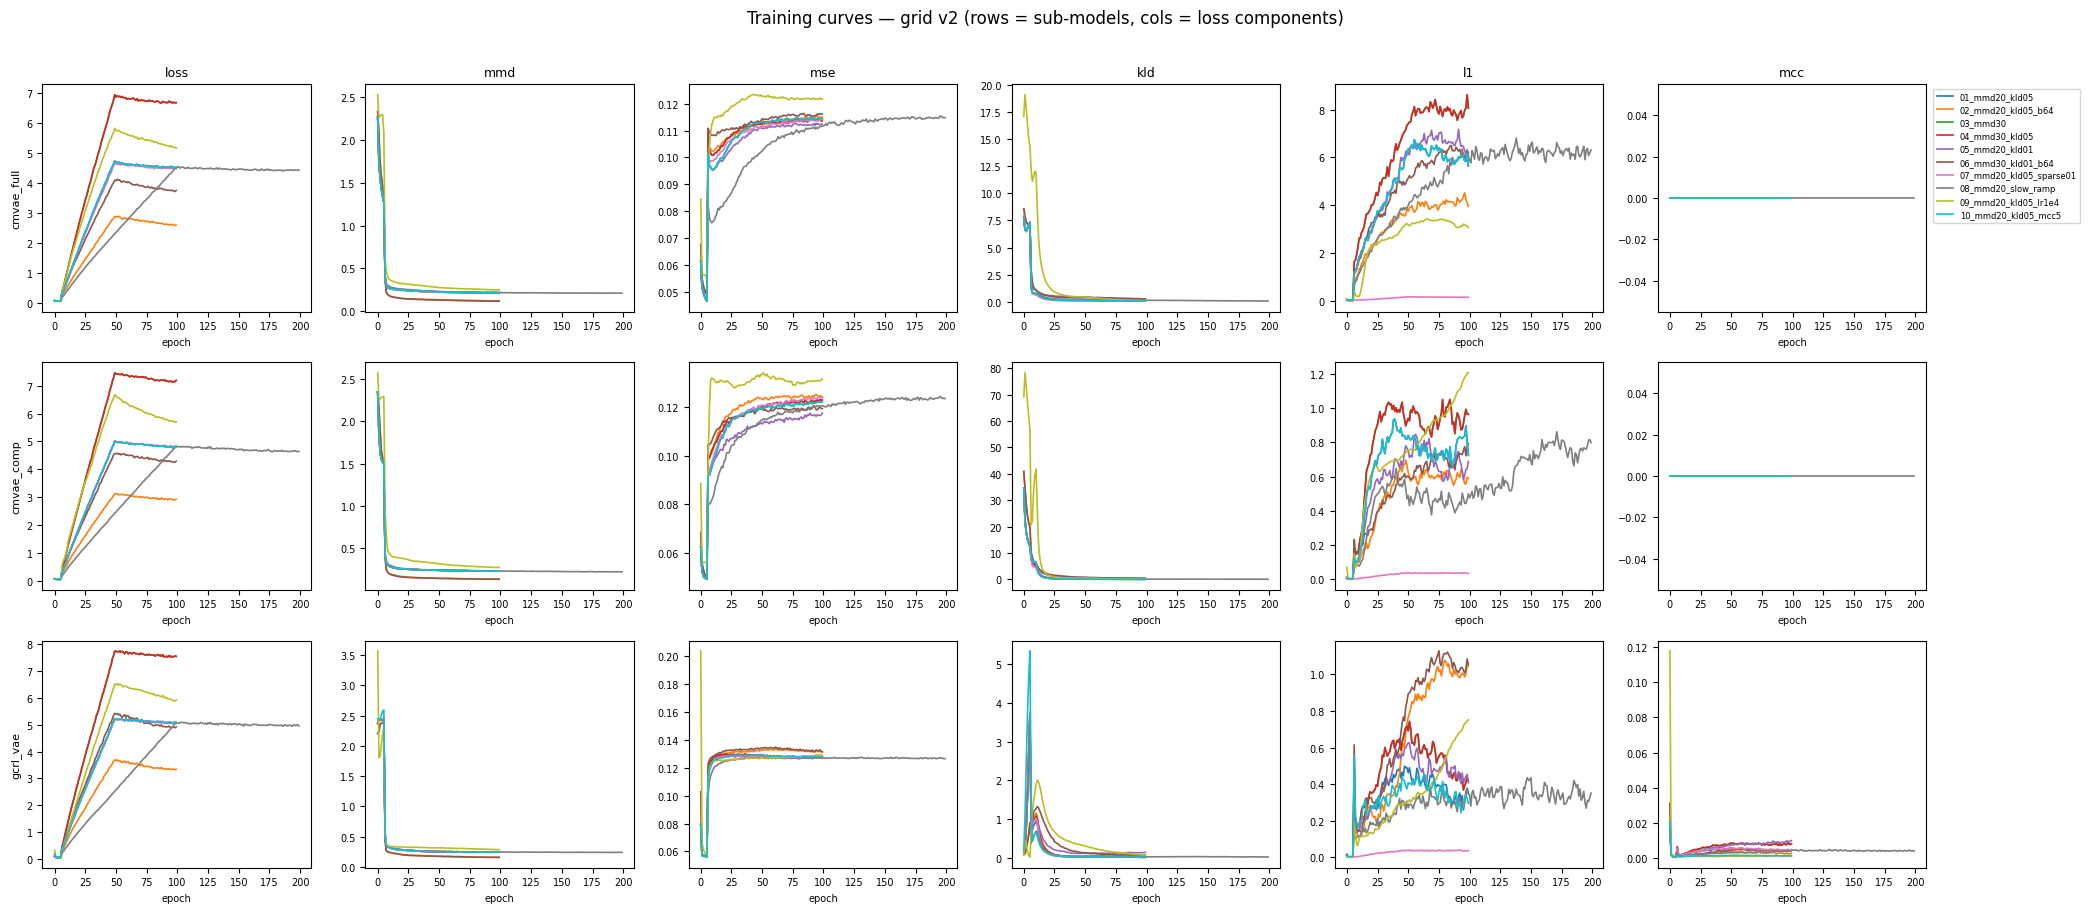

In [8]:
LOSS_COLS   = ["loss", "mmd", "mse", "kld", "l1", "mcc"]
sub_colors  = {"cmvae_full": "steelblue", "cmvae_comp": "darkorange", "gcrl_vae": "mediumseagreen"}
cmap        = plt.get_cmap("tab10")
set_styles  = {name: cmap(i % 10) for i, (name, _) in enumerate(SETTINGS)}

n_sub  = len(SUBMODELS)
n_cols = len(LOSS_COLS)
fig, axes = plt.subplots(n_sub, n_cols, figsize=(3.5 * n_cols, 3 * n_sub), squeeze=False)

for row, (sub_name, _) in enumerate(SUBMODELS):
    for col, lc in enumerate(LOSS_COLS):
        ax = axes[row, col]
        for name, _ in SETTINGS:
            df = histories[(name, sub_name)]
            if lc in df.columns:
                ax.plot(df["epoch"], df[lc], label=name, color=set_styles[name], linewidth=1.2)
        if row == 0:
            ax.set_title(lc, fontsize=9)
        if col == 0:
            ax.set_ylabel(sub_name, fontsize=8)
        ax.set_xlabel("epoch", fontsize=7)
        ax.tick_params(labelsize=7)
        if row == 0 and col == n_cols - 1:
            ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Training curves — grid v2 (rows = sub-models, cols = loss components)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Performance summary table

In [9]:
rows = []
for name, _ in SETTINGS:
    for sub_name, _ in SUBMODELS:
        df = metrics[(name, sub_name)]
        for metric_name in ["centroid_distance", "rmse"]:
            for method in ["actual", "worst_case", "perfect_baseline"]:
                val = df.loc[
                    (df["metric_name"] == metric_name) & (df["method"] == method),
                    "metric_value"
                ].median()
                rows.append({
                    "setting":  name,
                    "model":    sub_name,
                    "metric":   metric_name,
                    "method":   method,
                    "median":   val,
                })

summary = pd.DataFrame(rows)
pivot = summary.pivot_table(
    index=["setting", "model"],
    columns=["metric", "method"],
    values="median",
).round(4)
pivot = pivot.sort_values(("centroid_distance", "actual"))
print("Median metrics across all double-perturbation conditions (sorted by centroid_distance actual):")
pivot

Median metrics across all double-perturbation conditions (sorted by centroid_distance actual):


metric                             centroid_distance                   \
method                                        actual perfect_baseline   
setting                 model                                           
05_mmd20_kld01          cmvae_full            4.1652           1.8756   
06_mmd30_kld01_b64      cmvae_full            4.6450           1.8756   
10_mmd20_kld05_mcc5     cmvae_full            4.9240           1.8756   
01_mmd20_kld05          cmvae_full            4.9240           1.8756   
04_mmd30_kld05          cmvae_full            5.3866           1.8756   
03_mmd30                cmvae_full            5.3866           1.8756   
02_mmd20_kld05_b64      cmvae_full            5.4144           1.8756   
07_mmd20_kld05_sparse01 cmvae_full            5.4292           1.8756   
05_mmd20_kld01          gcrl_vae              5.5643           1.8756   
06_mmd30_kld01_b64      cmvae_comp            5.5702           1.8756   
08_mmd20_slow_ramp      gcrl_vae              6.3911           1.8756   
03_mmd30                gcrl_vae              6.5789           1.8756   
04_mmd30_kld05          gcrl_vae              6.5789           1.8756   
01_mmd20_kld05          gcrl_vae              6.6207           1.8756   
06_mmd30_kld01_b64      gcrl_vae              6.6510           1.8756   
07_mmd20_kld05_sparse01 gcrl_vae              6.6777           1.8756   
10_mmd20_kld05_mcc5     gcrl_vae              6.6928           1.8756   
02_mmd20_kld05_b64      gcrl_vae              6.7835           1.8756   
09_mmd20_kld05_lr1e4    cmvae_comp            7.1380           1.8756   
                        cmvae_full            7.6688           1.8756   
01_mmd20_kld05          cmvae_comp            7.7431           1.8756   
10_mmd20_kld05_mcc5     cmvae_comp            7.7431           1.8756   
02_mmd20_kld05_b64      cmvae_comp            7.7762           1.8756   
03_mmd30                cmvae_comp            8.2279           1.8756   
04_mmd30_kld05          cmvae_comp            8.2279           1.8756   
07_mmd20_kld05_sparse01 cmvae_comp            8.5803           1.8756   
05_mmd20_kld01          cmvae_comp            8.9381           1.8756   
08_mmd20_slow_ramp      cmvae_full            9.3037           1.8756   
09_mmd20_kld05_lr1e4    gcrl_vae              9.6393           1.8756   
08_mmd20_slow_ramp      cmvae_comp           11.2145           1.8756   

metric                                           rmse                   \
method                             worst_case  actual perfect_baseline   
setting                 model                                            
05_mmd20_kld01          cmvae_full     5.4667  0.0801           0.0361   
06_mmd30_kld01_b64      cmvae_full     5.4667  0.0893           0.0361   
10_mmd20_kld05_mcc5     cmvae_full     5.4667  0.0947           0.0361   
01_mmd20_kld05          cmvae_full     5.4667  0.0947           0.0361   
04_mmd30_kld05          cmvae_full     5.4667  0.1036           0.0361   
03_mmd30                cmvae_full     5.4667  0.1036           0.0361   
02_mmd20_kld05_b64      cmvae_full     5.4667  0.1041           0.0361   
07_mmd20_kld05_sparse01 cmvae_full     5.4667  0.1044           0.0361   
05_mmd20_kld01          gcrl_vae       5.4667  0.1070           0.0361   
06_mmd30_kld01_b64      cmvae_comp     5.4667  0.1071           0.0361   
08_mmd20_slow_ramp      gcrl_vae       5.4667  0.1229           0.0361   
03_mmd30                gcrl_vae       5.4667  0.1265           0.0361   
04_mmd30_kld05          gcrl_vae       5.4667  0.1265           0.0361   
01_mmd20_kld05          gcrl_vae       5.4667  0.1273           0.0361   
06_mmd30_kld01_b64      gcrl_vae       5.4667  0.1279           0.0361   
07_mmd20_kld05_sparse01 gcrl_vae       5.4667  0.1284           0.0361   
10_mmd20_kld05_mcc5     gcrl_vae       5.4667  0.1287           0.0361   
02_mmd20_kld05_b64      gcrl_vae       5.4667  0.1305           0.0361   
09_mmd20_kld05_lr1e4    cmvae_comp  

## 7. Best setting per model

In [10]:
print("Best setting per model (by median RMSE actual):")
print(f"{'Model':<14} {'Best setting':<30} {'centroid_dist':>15} {'rmse':>10}")
print("-" * 72)
wc_ref = summary.query("metric == 'centroid_distance' and method == 'worst_case'")["median"].iloc[0]

for sub_name, _ in SUBMODELS:
    sub = summary[(summary["model"] == sub_name) &
                  (summary["metric"] == "rmse") &
                  (summary["method"] == "actual")]
    best_setting = sub.loc[sub["median"].idxmin(), "setting"]
    cd = summary[
        (summary["model"]  == sub_name) &
        (summary["setting"] == best_setting) &
        (summary["metric"] == "centroid_distance") &
        (summary["method"] == "actual")
    ]["median"].values[0]
    rm = sub[sub["setting"] == best_setting]["median"].values[0]
    print(f"{sub_name:<14} {best_setting:<30} {cd:>15.4f} {rm:>10.4f}  (worst_case cd={wc_ref:.4f})")

Best setting per model (by median RMSE actual):
Model          Best setting                     centroid_dist       rmse
------------------------------------------------------------------------
cmvae_full     05_mmd20_kld01                          4.1652     0.0801  (worst_case cd=5.4667)
cmvae_comp     06_mmd30_kld01_b64                      5.5702     0.1071  (worst_case cd=5.4667)
gcrl_vae       05_mmd20_kld01                          5.5643     0.1070  (worst_case cd=5.4667)


## 8. Bar chart: median centroid distance by setting and model

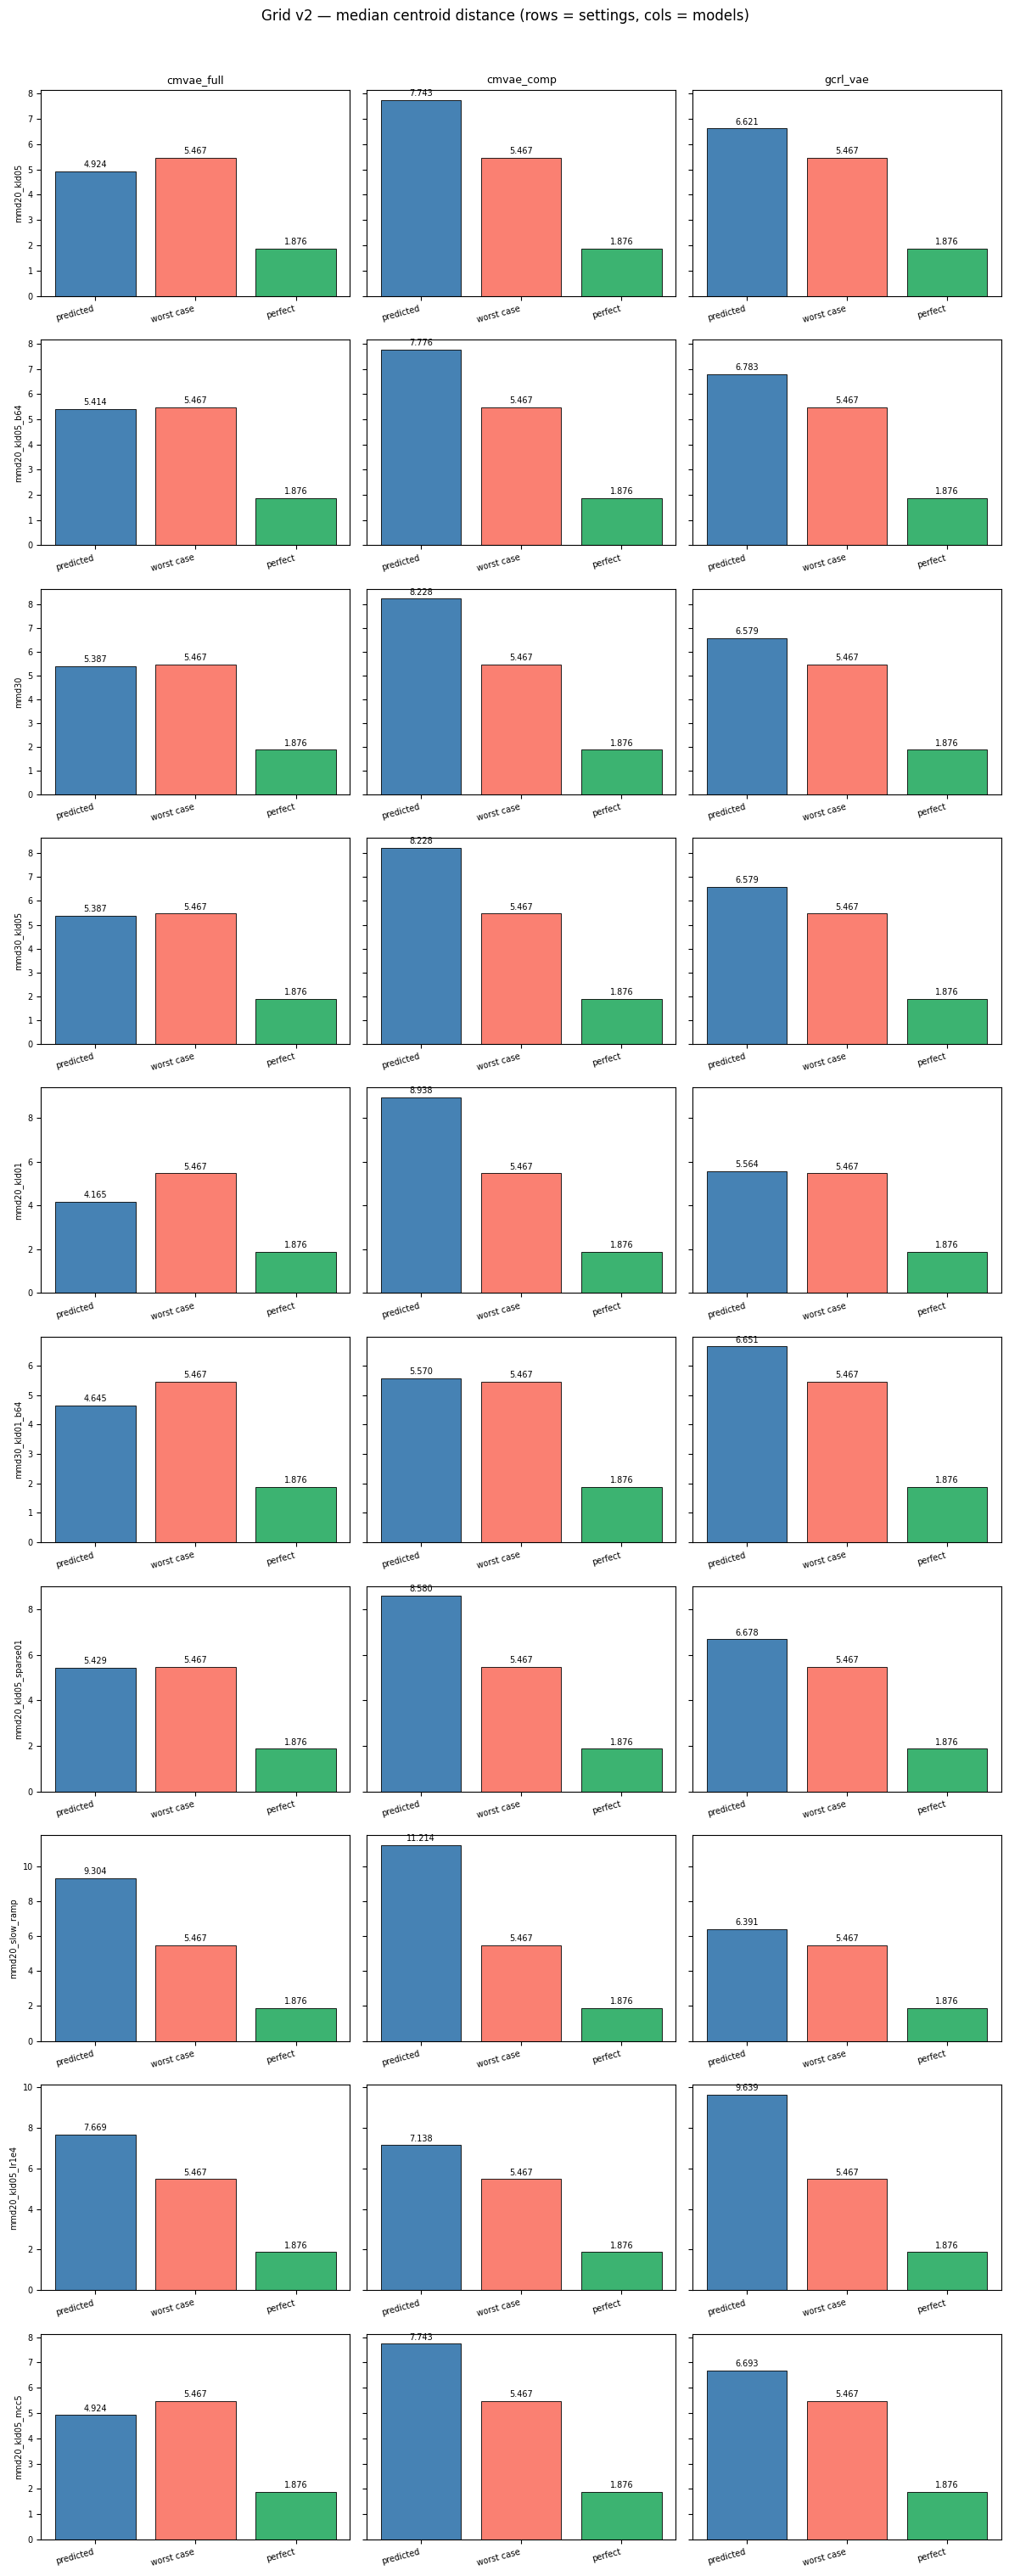

In [11]:
methods_order = ["actual", "worst_case", "perfect_baseline"]
method_colors = {"actual": "steelblue", "worst_case": "salmon", "perfect_baseline": "mediumseagreen"}

cd_df = summary[summary["metric"] == "centroid_distance"]

n_set = len(SETTINGS)
n_sub = len(SUBMODELS)
fig, axes = plt.subplots(n_set, n_sub, figsize=(4 * n_sub, 3 * n_set),
                         sharey="row", squeeze=False)

for row, (name, _) in enumerate(SETTINGS):
    for col, (sub_name, _) in enumerate(SUBMODELS):
        ax = axes[row, col]
        sub_df = cd_df[(cd_df["setting"] == name) & (cd_df["model"] == sub_name)]
        vals = sub_df.set_index("method")["median"].reindex(methods_order)
        bars = ax.bar(
            range(len(methods_order)), vals.values,
            color=[method_colors[m] for m in methods_order],
            edgecolor="k", linewidth=0.6,
        )
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=7)
        ax.set_xticks(range(len(methods_order)))
        ax.set_xticklabels(["predicted", "worst case", "perfect"], rotation=15, ha="right", fontsize=7)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel(name.split("_", 1)[1], fontsize=7)
        if row == 0:
            ax.set_title(sub_name, fontsize=9)

plt.suptitle("Grid v2 — median centroid distance (rows = settings, cols = models)", y=1.01)
plt.tight_layout()
plt.show()